In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load all datasets
stops   = pd.read_csv('data/bus_stops.csv')
trips   = pd.read_csv('data/bus_trips.csv')
arr     = pd.read_csv('data/stop_arrivals.csv')
flow    = pd.read_csv('data/passenger_flow.csv')
weather = pd.read_csv('data/weather_observations.csv')

print("✅ All files loaded!")
print(f"\n📄 bus_stops:         {stops.shape[0]} rows, {stops.shape[1]} cols")
print(f"📄 bus_trips:         {trips.shape[0]} rows, {trips.shape[1]} cols")
print(f"📄 stop_arrivals:     {arr.shape[0]} rows, {arr.shape[1]} cols")
print(f"📄 passenger_flow:    {flow.shape[0]} rows, {flow.shape[1]} cols")
print(f"📄 weather:           {weather.shape[0]} rows, {weather.shape[1]} cols")

✅ All files loaded!

📄 bus_stops:         62 rows, 13 cols
📄 bus_trips:         13440 rows, 22 cols
📄 stop_arrivals:     4478 rows, 24 cols
📄 passenger_flow:    3568 rows, 15 cols
📄 weather:           300 rows, 17 cols


In [2]:
for name, df in [("bus_stops", stops), ("bus_trips", trips), 
                  ("stop_arrivals", arr), ("passenger_flow", flow), 
                  ("weather", weather)]:
    print(f"\n{'='*55}")
    print(f"📄 {name} — {df.shape[0]} rows x {df.shape[1]} cols")
    print(f"{'='*55}")
    print(df.dtypes)
    print(f"\nFirst row sample:")
    print(df.iloc[0])


📄 bus_stops — 62 rows x 13 cols
stop_id                       object
line_id                       object
line_name                     object
stop_sequence                  int64
latitude                     float64
longitude                    float64
stop_type                     object
is_terminal                    int64
is_transfer_hub                int64
distance_from_prev_km        float64
scheduled_travel_time_min    float64
shelter_available              int64
bench_available                int64
dtype: object

First row sample:
stop_id                                 STP-L01-01
line_id                                        L01
line_name                    Merkez - Universitesi
stop_sequence                                    1
latitude                                 39.624179
longitude                                37.061303
stop_type                                 terminal
is_terminal                                      1
is_transfer_hub                              

In [6]:
print("MISSING VALUES CHECK")
print("="*55)

for name, df in [("bus_stops", stops), ("bus_trips", trips), 
                  ("stop_arrivals", arr), ("passenger_flow", flow), 
                  ("weather", weather)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    pct = (df.isnull().sum() / len(df) * 100).round(2)
    pct = pct[pct > 0]
    
    print(f"\n📄 {name}:")
    if len(missing) == 0:
        print("  ✅ No missing values!")
    else:
        for col in missing.index:
            print(f"  ⚠️  {col}: {missing[col]} missing ({pct[col]}%)")

print("\n\n UNIQUE VALUES IN CATEGORICAL COLUMNS")
print("="*55)

print("\n📄 stop_arrivals:")
for col in ['stop_type', 'weather_condition', 'traffic_level', 'time_bucket']:
    print(f"  {col}: {arr[col].unique()}")

print("\n📄 bus_trips:")
for col in ['weather_condition', 'traffic_level']:
    print(f"  {col}: {trips[col].unique()}")

print("\n📄 passenger_flow:")
for col in ['crowding_level', 'time_bucket']:
    print(f"  {col}: {flow[col].unique()}")

MISSING VALUES CHECK

📄 bus_stops:
  ✅ No missing values!

📄 bus_trips:
  ✅ No missing values!

📄 stop_arrivals:
  ✅ No missing values!

📄 passenger_flow:
  ✅ No missing values!

📄 weather:
  ✅ No missing values!


 UNIQUE VALUES IN CATEGORICAL COLUMNS

📄 stop_arrivals:
  stop_type: ['terminal' 'regular' 'university' 'hospital' 'residential' 'market']
  weather_condition: ['fog' 'cloudy' 'clear' 'snow' 'rain' 'wind']
  traffic_level: ['moderate' 'high' 'low' 'congested']
  time_bucket: ['evening' 'midday' 'evening_rush' 'early_morning' 'morning_rush' 'lunch'
 'afternoon']

📄 bus_trips:
  weather_condition: ['cloudy' 'rain' 'snow' 'wind' 'clear' 'fog']
  traffic_level: ['low' 'moderate' 'congested' 'high']

📄 passenger_flow:
  crowding_level: ['crowded' 'busy' 'moderate' 'light' 'empty']
  time_bucket: ['early_morning' 'morning_rush' 'midday' 'lunch' 'evening_rush' 'evening']


In [7]:
print("DELAY ANALYSIS")
print("="*55)

# Basic stats
print("\n delay_min stats (stop_arrivals):")
print(arr['delay_min'].describe().round(2))

print(f"\n  % delayed > 2 min:  {(arr['is_delayed'].sum()/len(arr)*100):.1f}%")
print(f"  % early (negative): {(arr['delay_min'] < 0).sum()/len(arr)*100:.1f}%")
print(f"  % on time (-2 to 2):{((arr['delay_min'] >= -2) & (arr['delay_min'] <= 2)).sum()/len(arr)*100:.1f}%")

print("\n📄 delay_min by traffic_level:")
print(arr.groupby('traffic_level')['delay_min'].agg(['mean','min','max','count']).round(2))

print("\n📄 delay_min by weather_condition:")
print(arr.groupby('weather_condition')['delay_min'].agg(['mean','min','max','count']).round(2))

print("\n📄 delay_min by time_bucket:")
print(arr.groupby('time_bucket')['delay_min'].agg(['mean','count']).round(2).sort_values('mean', ascending=False))

print("\n📄 delay_min by stop_type:")
print(arr.groupby('stop_type')['delay_min'].agg(['mean','count']).round(2).sort_values('mean', ascending=False))

DELAY ANALYSIS

 delay_min stats (stop_arrivals):
count    4478.00
mean        8.15
std        10.65
min        -2.40
25%         1.20
50%         4.30
75%        10.88
max        90.20
Name: delay_min, dtype: float64

  % delayed > 2 min:  66.3%
  % early (negative): 7.4%
  % on time (-2 to 2):33.6%

📄 delay_min by traffic_level:
                mean  min   max  count
traffic_level                         
congested      24.54  1.7  90.2    462
high           13.45  0.6  59.9    967
low             1.81 -2.4  19.6   1354
moderate        5.73  0.1  36.7   1695

📄 delay_min by weather_condition:
                    mean  min   max  count
weather_condition                         
clear               5.50 -2.4  55.2   1695
cloudy              5.95 -1.4  55.2   1114
fog                12.52  0.3  56.7    379
rain               10.17  0.2  63.2    605
snow               16.63  0.6  90.2    464
wind                8.88  0.1  60.6    221

📄 delay_min by time_bucket:
                mean  cou

In [8]:
print("CROWD / PASSENGERS ANALYSIS")
print("="*55)

print("\n📄 passengers_waiting stats:")
print(arr['passengers_waiting'].describe().round(2))

print("\n📄 passengers_waiting by hour_of_day:")
print(arr.groupby('hour_of_day')['passengers_waiting'].agg(['mean','max','count']).round(2))

print("\n📄 passengers_waiting by stop_type:")
print(arr.groupby('stop_type')['passengers_waiting'].agg(['mean','max','count']).round(2).sort_values('mean', ascending=False))

print("\n📄 passengers_waiting by weather_condition:")
print(arr.groupby('weather_condition')['passengers_waiting'].agg(['mean','max','count']).round(2).sort_values('mean', ascending=False))

print("\n📄 passengers_waiting by traffic_level:")
print(arr.groupby('traffic_level')['passengers_waiting'].agg(['mean','max','count']).round(2).sort_values('mean', ascending=False))

print("\n📄 passengers_waiting by time_bucket:")
print(arr.groupby('time_bucket')['passengers_waiting'].agg(['mean','max','count']).round(2).sort_values('mean', ascending=False))

print("\n📄 passengers_waiting by is_weekend:")
print(arr.groupby('is_weekend')['passengers_waiting'].agg(['mean','max','count']).round(2))

print("\n📄 crowding_level distribution (from passenger_flow):")
print(flow['crowding_level'].value_counts())

CROWD / PASSENGERS ANALYSIS

📄 passengers_waiting stats:
count    4478.00
mean       34.24
std        26.56
min         4.00
25%        14.00
50%        28.00
75%        46.00
max       180.00
Name: passengers_waiting, dtype: float64

📄 passengers_waiting by hour_of_day:
              mean  max  count
hour_of_day                   
5            28.84   89    282
6            28.28   79    317
7            67.12  180    232
8            54.14  176    311
9            29.48   89    252
10           25.92   88    343
11           22.40   62    274
12           35.17  103    296
13           35.58  106    218
14           28.55   80    149
15           26.19   71    213
16           25.38   79    141
17           45.87  131    201
18           64.14  174    201
19           24.46   76    188
20           25.02   65    264
21           26.56   72    227
22           28.28   90    369

📄 passengers_waiting by stop_type:
              mean  max  count
stop_type                     
university

In [9]:
print("CORRELATION ANALYSIS")
print("="*55)

# Numeric columns for correlation
numeric_cols = [
    'delay_min', 'cumulative_delay_min', 'speed_factor',
    'passengers_waiting', 'passengers_boarding', 'passengers_alighting',
    'dwell_time_min', 'hour_of_day', 'stop_sequence',
    'minutes_to_next_bus', 'is_weekend', 'is_delayed'
]

corr_matrix = arr[numeric_cols].corr().round(3)

print("\n📄 Top correlations with delay_min:")
delay_corr = corr_matrix['delay_min'].drop('delay_min').sort_values(ascending=False)
for col, val in delay_corr.items():
    bar = '█' * int(abs(val) * 20)
    direction = '↑' if val > 0 else '↓'
    print(f"  {direction} {col:<30} {val:>6.3f}  {bar}")

print("\n📄 Top correlations with passengers_waiting:")
crowd_corr = corr_matrix['passengers_waiting'].drop('passengers_waiting').sort_values(ascending=False)
for col, val in crowd_corr.items():
    bar = '█' * int(abs(val) * 20)
    direction = '↑' if val > 0 else '↓'
    print(f"  {direction} {col:<30} {val:>6.3f}  {bar}")

print("\n📄 Correlation: speed_factor vs delay_min:")
print(f"  {arr['speed_factor'].corr(arr['delay_min']):.3f}")

print("\n📄 Correlation: minutes_to_next_bus vs passengers_waiting:")
print(f"  {arr['minutes_to_next_bus'].corr(arr['passengers_waiting']):.3f}")

CORRELATION ANALYSIS

📄 Top correlations with delay_min:
  ↑ cumulative_delay_min            1.000  ████████████████████
  ↑ is_delayed                      0.507  ██████████
  ↑ stop_sequence                   0.447  ████████
  ↑ minutes_to_next_bus             0.368  ███████
  ↑ passengers_waiting              0.196  ███
  ↑ passengers_boarding             0.145  ██
  ↑ dwell_time_min                  0.142  ██
  ↑ passengers_alighting            0.075  █
  ↓ hour_of_day                    -0.063  █
  ↓ is_weekend                     -0.165  ███
  ↓ speed_factor                   -0.706  ██████████████

📄 Top correlations with passengers_waiting:
  ↑ passengers_boarding             0.734  ██████████████
  ↑ dwell_time_min                  0.696  █████████████
  ↑ passengers_alighting            0.403  ████████
  ↑ delay_min                       0.196  ███
  ↑ cumulative_delay_min            0.196  ███
  ↑ is_delayed                      0.077  █
  ↑ minutes_to_next_bus             0

📊 GENERATING VISUALIZATIONS...


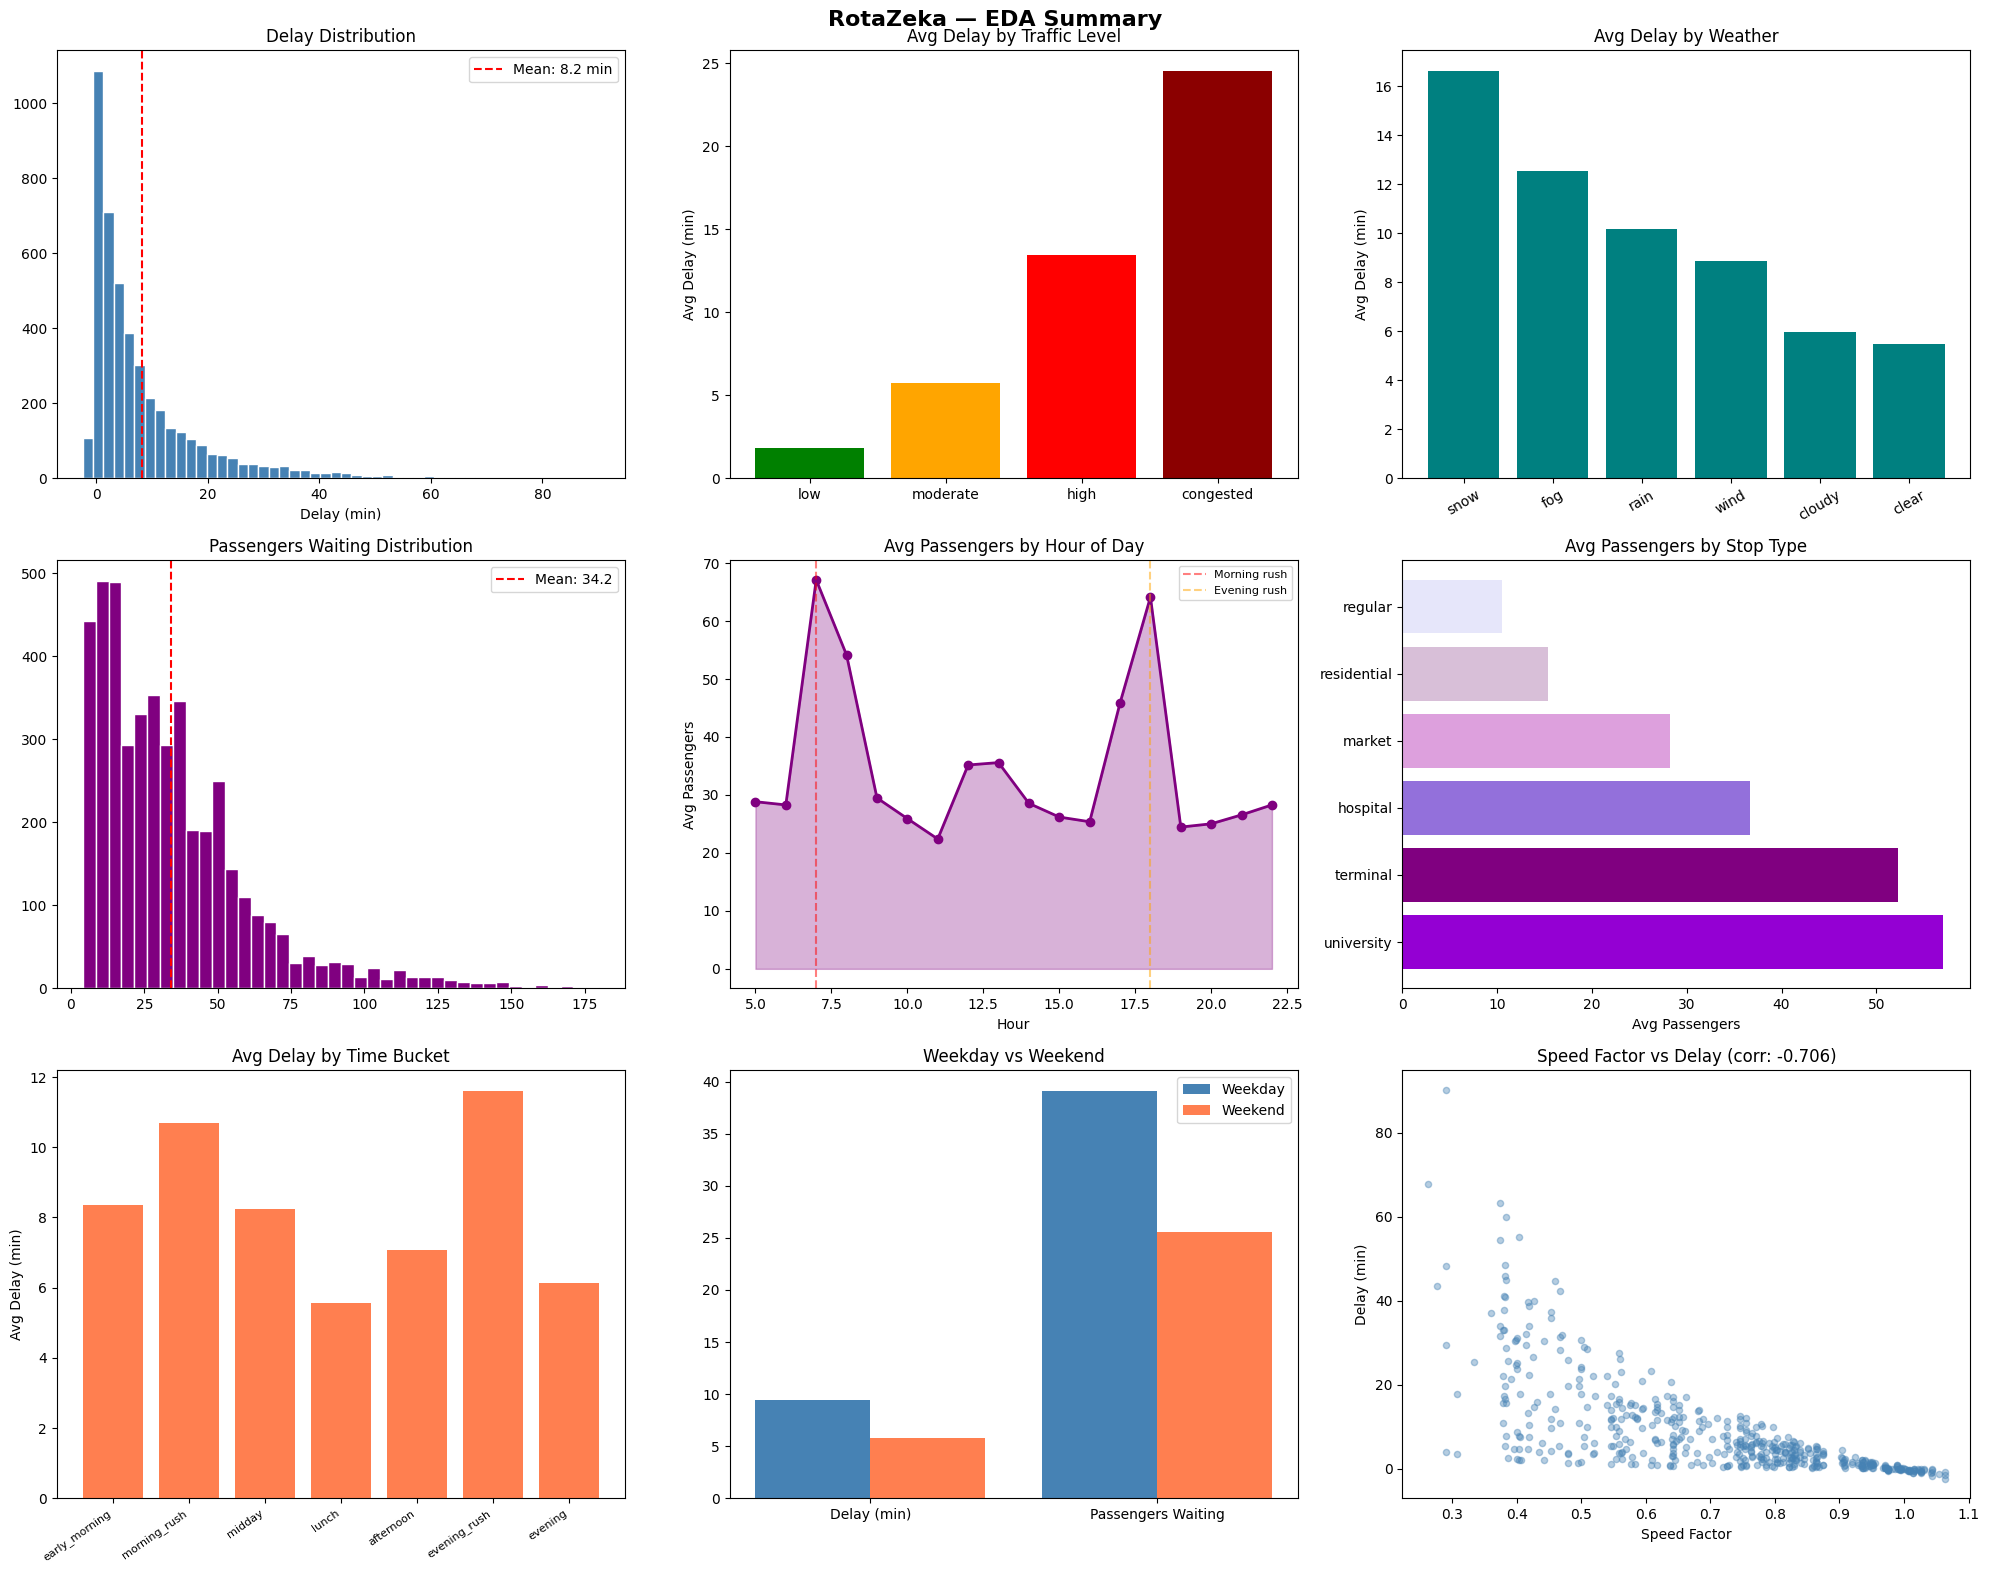

✅ Plot saved to data/eda_summary.png


In [10]:
print("📊 GENERATING VISUALIZATIONS...")

fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.suptitle('RotaZeka — EDA Summary', fontsize=16, fontweight='bold')

# 1. Delay distribution
axes[0,0].hist(arr['delay_min'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].axvline(arr['delay_min'].mean(), color='red', linestyle='--', label=f"Mean: {arr['delay_min'].mean():.1f} min")
axes[0,0].set_title('Delay Distribution')
axes[0,0].set_xlabel('Delay (min)')
axes[0,0].legend()

# 2. Delay by traffic level
traffic_order = ['low', 'moderate', 'high', 'congested']
traffic_delays = arr.groupby('traffic_level')['delay_min'].mean().reindex(traffic_order)
axes[0,1].bar(traffic_order, traffic_delays, color=['green','orange','red','darkred'])
axes[0,1].set_title('Avg Delay by Traffic Level')
axes[0,1].set_ylabel('Avg Delay (min)')

# 3. Delay by weather
weather_delays = arr.groupby('weather_condition')['delay_min'].mean().sort_values(ascending=False)
axes[0,2].bar(weather_delays.index, weather_delays.values, color='teal')
axes[0,2].set_title('Avg Delay by Weather')
axes[0,2].set_ylabel('Avg Delay (min)')
axes[0,2].tick_params(axis='x', rotation=30)

# 4. Passengers waiting distribution
axes[1,0].hist(arr['passengers_waiting'], bins=40, color='purple', edgecolor='white')
axes[1,0].axvline(arr['passengers_waiting'].mean(), color='red', linestyle='--', label=f"Mean: {arr['passengers_waiting'].mean():.1f}")
axes[1,0].set_title('Passengers Waiting Distribution')
axes[1,0].legend()

# 5. Passengers by hour
hourly = arr.groupby('hour_of_day')['passengers_waiting'].mean()
axes[1,1].plot(hourly.index, hourly.values, color='purple', marker='o', linewidth=2)
axes[1,1].fill_between(hourly.index, hourly.values, alpha=0.3, color='purple')
axes[1,1].set_title('Avg Passengers by Hour of Day')
axes[1,1].set_xlabel('Hour')
axes[1,1].set_ylabel('Avg Passengers')
axes[1,1].axvline(7, color='red', linestyle='--', alpha=0.5, label='Morning rush')
axes[1,1].axvline(18, color='orange', linestyle='--', alpha=0.5, label='Evening rush')
axes[1,1].legend(fontsize=8)

# 6. Passengers by stop type
stop_crowd = arr.groupby('stop_type')['passengers_waiting'].mean().sort_values(ascending=False)
colors = ['darkviolet','purple','mediumpurple','plum','thistle','lavender']
axes[1,2].barh(stop_crowd.index, stop_crowd.values, color=colors)
axes[1,2].set_title('Avg Passengers by Stop Type')
axes[1,2].set_xlabel('Avg Passengers')

# 7. Delay by time bucket
time_order = ['early_morning','morning_rush','midday','lunch','afternoon','evening_rush','evening']
time_delays = arr.groupby('time_bucket')['delay_min'].mean().reindex(time_order)
axes[2,0].bar(range(len(time_order)), time_delays.values, color='coral')
axes[2,0].set_xticks(range(len(time_order)))
axes[2,0].set_xticklabels(time_order, rotation=35, ha='right', fontsize=8)
axes[2,0].set_title('Avg Delay by Time Bucket')
axes[2,0].set_ylabel('Avg Delay (min)')

# 8. Weekend vs weekday
categories = ['Delay (min)', 'Passengers Waiting']
weekend_vals = [arr[arr['is_weekend']==1]['delay_min'].mean(),
                arr[arr['is_weekend']==1]['passengers_waiting'].mean()]
weekday_vals = [arr[arr['is_weekend']==0]['delay_min'].mean(),
                arr[arr['is_weekend']==0]['passengers_waiting'].mean()]
x = np.arange(len(categories))
axes[2,1].bar(x - 0.2, weekday_vals, 0.4, label='Weekday', color='steelblue')
axes[2,1].bar(x + 0.2, weekend_vals, 0.4, label='Weekend', color='coral')
axes[2,1].set_xticks(x)
axes[2,1].set_xticklabels(categories)
axes[2,1].set_title('Weekday vs Weekend')
axes[2,1].legend()

# 9. Speed factor vs delay scatter
sample = arr.sample(500, random_state=42)
axes[2,2].scatter(sample['speed_factor'], sample['delay_min'], 
                  alpha=0.4, color='steelblue', s=20)
axes[2,2].set_title(f'Speed Factor vs Delay (corr: -0.706)')
axes[2,2].set_xlabel('Speed Factor')
axes[2,2].set_ylabel('Delay (min)')

plt.tight_layout()
plt.savefig('data/eda_summary.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Plot saved to data/eda_summary.png")

In [11]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           ROTAZEKA — EDA KEY FINDINGS SUMMARY                ║
║        Share this with teammates before modeling!            ║
╚══════════════════════════════════════════════════════════════╝

📁 DATASET OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  bus_stops:        62 rows  — static stop metadata
  bus_trips:     13440 rows  — one row per trip
  stop_arrivals:  4478 rows  — MAIN ML TABLE ⭐
  passenger_flow: 3568 rows  — aggregated crowd stats
  weather:         300 rows  — weather readings
  Missing values: NONE in any table ✅

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🎯 MODEL 1 — DELAY PREDICTION (Person 2: 02_delay_model.ipynb)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Target column : delay_min (from stop_arrivals.csv)
  Metric        : MAE (lower is better)

  Target stats:
    Mean delay  : 8.15 min
    Max delay   : 90.2 min
    % delayed   : 66.3% (> 2 min threshold)
    % early     : 7.4%
    % on time   : 33.6%

  🔑 BEST FEATURES (use these!):
    1. speed_factor          corr = -0.706  ⭐ STRONGEST
    2. cumulative_delay_min  corr = +1.000  ⭐ STRONGEST
    3. stop_sequence         corr = +0.447
    4. minutes_to_next_bus   corr = +0.368
    5. is_weekend            corr = -0.165
    6. traffic_level         (encode: low=1 mod=2 high=3 cong=4)
    7. weather_condition     (encode: clear→snow by severity)
    8. hour_of_day           (cyclical or as-is)
    9. time_bucket           (morning_rush worst: 10.69 min)

  ⚠️  IMPORTANT NOTES FOR MODELING:
    - congested traffic → avg 24.54 min delay (4x vs low!)
    - snow → avg 16.63 min delay (worst weather)
    - fog  → avg 12.52 min delay
    - morning_rush & evening_rush = highest delays
    - weekend delays are LOWER (-0.165 correlation)
    - delay_min has outliers (max=90.2) → consider clipping at 60

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
👥 MODEL 2 — CROWD PREDICTION (Person 3: 03_crowd_model.ipynb)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Target column : passengers_waiting (from stop_arrivals.csv)
  Metric        : RMSE (lower is better)

  Target stats:
    Mean        : 34.24 passengers
    Std         : 26.56 (high variance!)
    Min / Max   : 4 / 180
    Median      : 28

  🔑 BEST FEATURES (use these!):
    1. stop_type             ⭐ STRONGEST SIGNAL
         university → 57.08 avg  (highest!)
         terminal   → 52.28 avg
         hospital   → 36.64 avg
         market     → 28.25 avg
         residential→ 15.38 avg
         regular    → 10.53 avg  (lowest)
    2. hour_of_day           ⭐ STRONGEST SIGNAL
         07:00 → 67.12 avg  (morning peak!)
         18:00 → 64.14 avg  (evening peak!)
         11:00 → 22.40 avg  (quietest)
    3. is_weekend            corr = -0.245
         weekday → 39.13 avg
         weekend → 25.57 avg  (much quieter!)
    4. weather_condition
         rain  → 44.85 avg  (most crowded!)
         snow  → 40.49 avg
         clear → 29.81 avg  (least crowded)
    5. passengers_boarding   corr = +0.734
    6. dwell_time_min        corr = +0.696
    7. speed_factor          corr = -0.234
    8. traffic_level
         congested → 45.59 avg
         low       → 29.25 avg
    9. time_bucket
         morning_rush → 59.68 avg  (peak!)
         evening_rush → 45.27 avg
         midday       → 25.84 avg  (quietest)

  ⚠️  IMPORTANT NOTES FOR MODELING:
    - std=26.56 is high → tree models handle this better than linear
    - university & terminal stops are VERY different from regular stops
    - rain increases crowd by ~50% vs clear weather
    - minutes_to_next_bus has LOW correlation (0.056) — less useful
    - merge with passenger_flow.csv for avg_passengers_waiting feature

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🛠️  RECOMMENDED APPROACH FOR BOTH MODELS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Algorithm     : LightGBM (fast, handles categoricals well)
  Train/test    : 80/20 split, random_state=42
  Categorical   : use LabelEncoder for string columns
  Outliers      : clip delay_min at 60 before training
  
  Encode these columns before training:
    traffic_level    : low→0, moderate→1, high→2, congested→3
    weather_condition: clear→0, cloudy→1, wind→2, fog→3, rain→4, snow→5
    stop_type        : use LabelEncoder
    time_bucket      : use LabelEncoder

  Save models to:
    ~/project/models/delay_model.pkl
    ~/project/models/crowd_model.pkl
  
  Also save feature list:
    ~/project/models/delay_features.txt
    ~/project/models/crowd_features.txt
    (API team needs these to know what inputs to send!)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📂 DATA PATHS (all notebooks use same paths)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  stops   = pd.read_csv('data/bus_stops.csv')
  trips   = pd.read_csv('data/bus_trips.csv')
  arr     = pd.read_csv('data/stop_arrivals.csv')
  flow    = pd.read_csv('data/passenger_flow.csv')
  weather = pd.read_csv('data/weather_observations.csv')
  
  Working directory: /home/team-035/project/
  Models output   : /home/team-035/project/models/

✅ EDA COMPLETE — share this notebook with your team!
""")


╔══════════════════════════════════════════════════════════════╗
║           ROTAZEKA — EDA KEY FINDINGS SUMMARY                ║
║        Share this with teammates before modeling!            ║
╚══════════════════════════════════════════════════════════════╝

📁 DATASET OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  bus_stops:        62 rows  — static stop metadata
  bus_trips:     13440 rows  — one row per trip
  stop_arrivals:  4478 rows  — MAIN ML TABLE ⭐
  passenger_flow: 3568 rows  — aggregated crowd stats
  weather:         300 rows  — weather readings
  Missing values: NONE in any table ✅

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🎯 MODEL 1 — DELAY PREDICTION (Person 2: 02_delay_model.ipynb)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Target column : delay_min (from stop_arrivals.csv)
  Metric        : MAE (lower is better)

  Target stats:
    Mean delay  : 8.15 min
    Max delay   : 90.2 min
    % delayed   : 6

In [12]:
import pandas as pd
import numpy as np

# Load all datasets
stops   = pd.read_csv('data/bus_stops.csv')
trips   = pd.read_csv('data/bus_trips.csv')
arr     = pd.read_csv('data/stop_arrivals.csv')
flow    = pd.read_csv('data/passenger_flow.csv')
weather = pd.read_csv('data/weather_observations.csv')

print("✅ All loaded!")
print(f"stop_arrivals shape: {arr.shape}")

✅ All loaded!
stop_arrivals shape: (4478, 24)


In [13]:
# Encode traffic_level
traffic_map = {'low': 0, 'moderate': 1, 'high': 2, 'congested': 3}
arr['traffic_level_enc'] = arr['traffic_level'].map(traffic_map)

# Encode weather_condition
weather_map = {'clear': 0, 'cloudy': 1, 'wind': 2, 'fog': 3, 'rain': 4, 'snow': 5}
arr['weather_condition_enc'] = arr['weather_condition'].map(weather_map)

# Encode stop_type
stop_type_map = {'regular': 0, 'residential': 1, 'market': 2, 
                 'hospital': 3, 'terminal': 4, 'university': 5}
arr['stop_type_enc'] = arr['stop_type'].map(stop_type_map)

# Encode time_bucket
time_map = {'early_morning': 0, 'morning_rush': 1, 'midday': 2, 
            'lunch': 3, 'afternoon': 4, 'evening_rush': 5, 'evening': 6}
arr['time_bucket_enc'] = arr['time_bucket'].map(time_map)

print("✅ Encoding done!")
print(arr[['traffic_level', 'traffic_level_enc', 
           'weather_condition', 'weather_condition_enc']].head(5))

✅ Encoding done!
  traffic_level  traffic_level_enc weather_condition  weather_condition_enc
0      moderate                  1               fog                      3
1      moderate                  1               fog                      3
2      moderate                  1               fog                      3
3      moderate                  1               fog                      3
4      moderate                  1               fog                      3


In [14]:
# Merge stop info (is_transfer_hub, is_terminal) from bus_stops
arr = arr.merge(
    stops[['stop_id', 'is_transfer_hub', 'is_terminal', 'distance_from_prev_km']],
    on='stop_id',
    how='left'
)

# Merge avg_passengers_waiting baseline from passenger_flow
flow_agg = flow.groupby(['stop_id', 'hour_of_day', 'day_of_week'])\
               ['avg_passengers_waiting'].mean().reset_index()
flow_agg.columns = ['stop_id', 'hour_of_day', 'day_of_week', 'baseline_crowd']

arr = arr.merge(flow_agg, on=['stop_id', 'hour_of_day', 'day_of_week'], how='left')

# Fill any unmatched baseline with overall mean
arr['baseline_crowd'] = arr['baseline_crowd'].fillna(arr['passengers_waiting'].mean())

print("✅ Merge done!")
print(f"Shape after merge: {arr.shape}")
print(arr[['stop_id', 'is_transfer_hub', 'is_terminal', 'baseline_crowd']].head(5))

✅ Merge done!
Shape after merge: (4478, 32)
      stop_id  is_transfer_hub  is_terminal  baseline_crowd
0  STP-L01-01                0            1       34.238723
1  STP-L01-02                0            0        7.000000
2  STP-L01-03                0            0       34.238723
3  STP-L01-04                0            0       34.238723
4  STP-L01-05                0            0       30.500000


In [15]:
print("📊 Before clipping:")
print(f"  delay_min max: {arr['delay_min'].max()}")
print(f"  passengers_waiting max: {arr['passengers_waiting'].max()}")

# Clip delay outliers at 60 min
arr['delay_min_clipped'] = arr['delay_min'].clip(upper=60)

# Keep passengers as-is (180 is realistic for university stops)
print("\n📊 After clipping:")
print(f"  delay_min_clipped max: {arr['delay_min_clipped'].max()}")
print(f"  Rows clipped: {(arr['delay_min'] > 60).sum()}")

📊 Before clipping:
  delay_min max: 90.2
  passengers_waiting max: 180

📊 After clipping:
  delay_min_clipped max: 60.0
  Rows clipped: 14


In [16]:
# Best features for delay prediction (from EDA)
delay_features = [
    # strongest features
    'cumulative_delay_min',
    'speed_factor',
    'stop_sequence',
    'minutes_to_next_bus',
    # time features
    'hour_of_day',
    'is_weekend',
    'time_bucket_enc',
    # condition features
    'traffic_level_enc',
    'weather_condition_enc',
    # stop features
    'stop_type_enc',
    'is_transfer_hub',
    'is_terminal',
    'distance_from_prev_km',
    # target
    'delay_min_clipped'
]

delay_df = arr[delay_features].copy()
delay_df = delay_df.rename(columns={'delay_min_clipped': 'target_delay_min'})

print("✅ DELAY DATASET ready!")
print(f"  Shape: {delay_df.shape}")
print(f"\n  Columns:")
for col in delay_df.columns:
    print(f"    {col}")
print(f"\n  Target stats:")
print(delay_df['target_delay_min'].describe().round(2))

✅ DELAY DATASET ready!
  Shape: (4478, 14)

  Columns:
    cumulative_delay_min
    speed_factor
    stop_sequence
    minutes_to_next_bus
    hour_of_day
    is_weekend
    time_bucket_enc
    traffic_level_enc
    weather_condition_enc
    stop_type_enc
    is_transfer_hub
    is_terminal
    distance_from_prev_km
    target_delay_min

  Target stats:
count    4478.00
mean        8.11
std        10.41
min        -2.40
25%         1.20
50%         4.30
75%        10.88
max        60.00
Name: target_delay_min, dtype: float64


In [17]:
# Best features for crowd prediction (from EDA)
crowd_features = [
    # strongest features
    'stop_type_enc',
    'hour_of_day',
    'is_weekend',
    'baseline_crowd',
    # time features
    'time_bucket_enc',
    'day_of_week',
    # condition features
    'weather_condition_enc',
    'traffic_level_enc',
    # stop features
    'is_transfer_hub',
    'is_terminal',
    # other useful
    'speed_factor',
    'dwell_time_min',
    'minutes_to_next_bus',
    # target
    'passengers_waiting'
]

crowd_df = arr[crowd_features].copy()
crowd_df = crowd_df.rename(columns={'passengers_waiting': 'target_passengers_waiting'})

print("✅ CROWD DATASET ready!")
print(f"  Shape: {crowd_df.shape}")
print(f"\n  Columns:")
for col in crowd_df.columns:
    print(f"    {col}")
print(f"\n  Target stats:")
print(crowd_df['target_passengers_waiting'].describe().round(2))

✅ CROWD DATASET ready!
  Shape: (4478, 14)

  Columns:
    stop_type_enc
    hour_of_day
    is_weekend
    baseline_crowd
    time_bucket_enc
    day_of_week
    weather_condition_enc
    traffic_level_enc
    is_transfer_hub
    is_terminal
    speed_factor
    dwell_time_min
    minutes_to_next_bus
    target_passengers_waiting

  Target stats:
count    4478.00
mean       34.24
std        26.56
min         4.00
25%        14.00
50%        28.00
75%        46.00
max       180.00
Name: target_passengers_waiting, dtype: float64


In [18]:
# Save to data folder
delay_df.to_csv('data/model_delay_dataset.csv', index=False)
crowd_df.to_csv('data/model_crowd_dataset.csv', index=False)

print("✅ SAVED!")
print(f"\n  📄 data/model_delay_dataset.csv")
print(f"     Shape : {delay_df.shape}")
print(f"     Target: target_delay_min")
print(f"     Mean  : {delay_df['target_delay_min'].mean():.2f} min")

print(f"\n  📄 data/model_crowd_dataset.csv")
print(f"     Shape : {crowd_df.shape}")
print(f"     Target: target_passengers_waiting")
print(f"     Mean  : {crowd_df['target_passengers_waiting'].mean():.2f} passengers")

print("\n👥 TELL YOUR FRIENDS:")
print("  Person 2 → use data/model_delay_dataset.csv")
print("             target column = 'target_delay_min'")
print("  Person 3 → use data/model_crowd_dataset.csv")
print("             target column = 'target_passengers_waiting'")

✅ SAVED!

  📄 data/model_delay_dataset.csv
     Shape : (4478, 14)
     Target: target_delay_min
     Mean  : 8.11 min

  📄 data/model_crowd_dataset.csv
     Shape : (4478, 14)
     Target: target_passengers_waiting
     Mean  : 34.24 passengers

👥 TELL YOUR FRIENDS:
  Person 2 → use data/model_delay_dataset.csv
             target column = 'target_delay_min'
  Person 3 → use data/model_crowd_dataset.csv
             target column = 'target_passengers_waiting'


In [19]:
print("🔧 FIXING DATA LEAKAGE...")
print("="*55)

# Reload clean data
arr = pd.read_csv('data/stop_arrivals.csv')
stops = pd.read_csv('data/bus_stops.csv')
flow = pd.read_csv('data/passenger_flow.csv')

# Re-encode categoricals
traffic_map = {'low': 0, 'moderate': 1, 'high': 2, 'congested': 3}
weather_map = {'clear': 0, 'cloudy': 1, 'wind': 2, 'fog': 3, 'rain': 4, 'snow': 5}
stop_type_map = {'regular': 0, 'residential': 1, 'market': 2,
                 'hospital': 3, 'terminal': 4, 'university': 5}
time_map = {'early_morning': 0, 'morning_rush': 1, 'midday': 2,
            'lunch': 3, 'afternoon': 4, 'evening_rush': 5, 'evening': 6}

arr['traffic_level_enc']     = arr['traffic_level'].map(traffic_map)
arr['weather_condition_enc'] = arr['weather_condition'].map(weather_map)
arr['stop_type_enc']         = arr['stop_type'].map(stop_type_map)
arr['time_bucket_enc']       = arr['time_bucket'].map(time_map)

# Merge stop metadata
arr = arr.merge(
    stops[['stop_id', 'is_transfer_hub', 'is_terminal', 'distance_from_prev_km']],
    on='stop_id', how='left'
)

# Merge baseline crowd
flow_agg = flow.groupby(['stop_id', 'hour_of_day', 'day_of_week'])\
               ['avg_passengers_waiting'].mean().reset_index()
flow_agg.columns = ['stop_id', 'hour_of_day', 'day_of_week', 'baseline_crowd']
arr = arr.merge(flow_agg, on=['stop_id', 'hour_of_day', 'day_of_week'], how='left')
arr['baseline_crowd'] = arr['baseline_crowd'].fillna(arr['passengers_waiting'].mean())

# ✅ Create PREVIOUS stop delay (valid real-time feature)
arr = arr.sort_values(['trip_id', 'stop_sequence'])
arr['prev_stop_delay'] = arr.groupby('trip_id')['delay_min'].shift(1)
arr['prev_stop_delay'] = arr['prev_stop_delay'].fillna(0)

# Clip delay outliers
arr['delay_min_clipped'] = arr['delay_min'].clip(upper=60)

print("✅ Features engineered!")
print(f"Shape: {arr.shape}")
print(f"\nSample prev_stop_delay vs delay_min:")
print(arr[['trip_id','stop_sequence','prev_stop_delay','delay_min']].head(8))

🔧 FIXING DATA LEAKAGE...
✅ Features engineered!
Shape: (4478, 34)

Sample prev_stop_delay vs delay_min:
        trip_id  stop_sequence  prev_stop_delay  delay_min
1484  TRP-00008              1              0.0        2.7
1485  TRP-00008              2              2.7        5.1
1486  TRP-00008              3              5.1        8.3
1487  TRP-00008              4              8.3       12.8
1488  TRP-00008              5             12.8       14.9
1489  TRP-00008              6             14.9       19.6
1490  TRP-00008              7             19.6       23.8
1491  TRP-00008              8             23.8       27.2


In [20]:
# ✅ NO leakage — only features known BEFORE bus arrives
delay_features_clean = [
    # strongest valid feature
    'prev_stop_delay',        # delay at PREVIOUS stop (known from tracking)
    # speed & conditions
    'speed_factor',           # current GPS speed factor
    'traffic_level_enc',      # real-time traffic
    'weather_condition_enc',  # current weather
    # time features
    'hour_of_day',
    'is_weekend',
    'day_of_week',
    'time_bucket_enc',
    # stop features
    'stop_sequence',
    'stop_type_enc',
    'distance_from_prev_km',
    'is_terminal',
    # target
    'delay_min_clipped'
]

delay_df_clean = arr[delay_features_clean].copy()
delay_df_clean = delay_df_clean.rename(columns={'delay_min_clipped': 'target_delay_min'})

print("✅ CLEAN DELAY DATASET ready!")
print(f"  Shape: {delay_df_clean.shape}")
print(f"  Features: {delay_df_clean.shape[1]-1}")
print(f"\n  Columns:")
for col in delay_df_clean.columns:
    print(f"    {'🎯' if col=='target_delay_min' else '  '} {col}")

✅ CLEAN DELAY DATASET ready!
  Shape: (4478, 13)
  Features: 12

  Columns:
       prev_stop_delay
       speed_factor
       traffic_level_enc
       weather_condition_enc
       hour_of_day
       is_weekend
       day_of_week
       time_bucket_enc
       stop_sequence
       stop_type_enc
       distance_from_prev_km
       is_terminal
    🎯 target_delay_min


In [21]:
# ✅ NO leakage — remove dwell_time_min (only known after bus leaves)
crowd_features_clean = [
    # strongest features (validated)
    'stop_type_enc',
    'hour_of_day',
    'baseline_crowd',         # historical average for this stop/hour
    # time features
    'time_bucket_enc',
    'day_of_week',
    'is_weekend',
    # conditions
    'weather_condition_enc',
    'traffic_level_enc',
    # other
    'speed_factor',
    'minutes_to_next_bus',
    # target
    'passengers_waiting'
]

crowd_df_clean = arr[crowd_features_clean].copy()
crowd_df_clean = crowd_df_clean.rename(columns={'passengers_waiting': 'target_passengers_waiting'})

print("✅ CLEAN CROWD DATASET ready!")
print(f"  Shape: {crowd_df_clean.shape}")
print(f"  Features: {crowd_df_clean.shape[1]-1}")
print(f"\n  Columns:")
for col in crowd_df_clean.columns:
    print(f"    {'🎯' if col=='target_passengers_waiting' else '  '} {col}")

✅ CLEAN CROWD DATASET ready!
  Shape: (4478, 11)
  Features: 10

  Columns:
       stop_type_enc
       hour_of_day
       baseline_crowd
       time_bucket_enc
       day_of_week
       is_weekend
       weather_condition_enc
       traffic_level_enc
       speed_factor
       minutes_to_next_bus
    🎯 target_passengers_waiting


In [22]:
delay_df_clean.to_csv('data/model_delay_dataset.csv', index=False)
crowd_df_clean.to_csv('data/model_crowd_dataset.csv', index=False)

print("✅ CLEAN DATASETS SAVED!")
print(f"\n  📄 data/model_delay_dataset.csv")
print(f"     Shape  : {delay_df_clean.shape}")
print(f"     Target : target_delay_min")
print(f"     Leakage: ❌ NONE")
print(f"\n  📄 data/model_crowd_dataset.csv")
print(f"     Shape  : {crowd_df_clean.shape}")
print(f"     Target : target_passengers_waiting")
print(f"     Leakage: ❌ NONE")
print(f"\n  ⚠️  OLD FILES OVERWRITTEN with clean versions")
print(f"\n👥 TELL YOUR FRIENDS:")
print(f"  data/model_delay_dataset.csv → target_delay_min")
print(f"  data/model_crowd_dataset.csv → target_passengers_waiting")
print(f"  Both datasets are leakage-free ✅")

✅ CLEAN DATASETS SAVED!

  📄 data/model_delay_dataset.csv
     Shape  : (4478, 13)
     Target : target_delay_min
     Leakage: ❌ NONE

  📄 data/model_crowd_dataset.csv
     Shape  : (4478, 11)
     Target : target_passengers_waiting
     Leakage: ❌ NONE

  ⚠️  OLD FILES OVERWRITTEN with clean versions

👥 TELL YOUR FRIENDS:
  data/model_delay_dataset.csv → target_delay_min
  data/model_crowd_dataset.csv → target_passengers_waiting
  Both datasets are leakage-free ✅


✅ Saved: data/model1_dataset.csv
   Shape : (4478, 31)
   Columns (31):
     traffic_level
     weather_condition
     traffic_level_enc
     weather_condition_enc
     prev_stop_delay
     speed_factor
     temperature_c
     precipitation_mm
     wind_speed_kmh
     humidity_pct
     hour_of_day
     is_weekend
     day_of_week
     stop_sequence
     distance_from_prev_km
     is_transfer_hub
     is_terminal
     stop_type_hospital
     stop_type_market
     stop_type_regular
     stop_type_residential
     stop_type_terminal
     stop_type_university
     time_bucket_afternoon
     time_bucket_early_morning
     time_bucket_evening
     time_bucket_evening_rush
     time_bucket_lunch
     time_bucket_midday
     time_bucket_morning_rush
     target_delay_min

Correlations with target_delay_min:
  + prev_stop_delay                      0.945  ████████████████████████████
  + traffic_level_enc                    0.662  ███████████████████
  + stop_sequence                        0.4

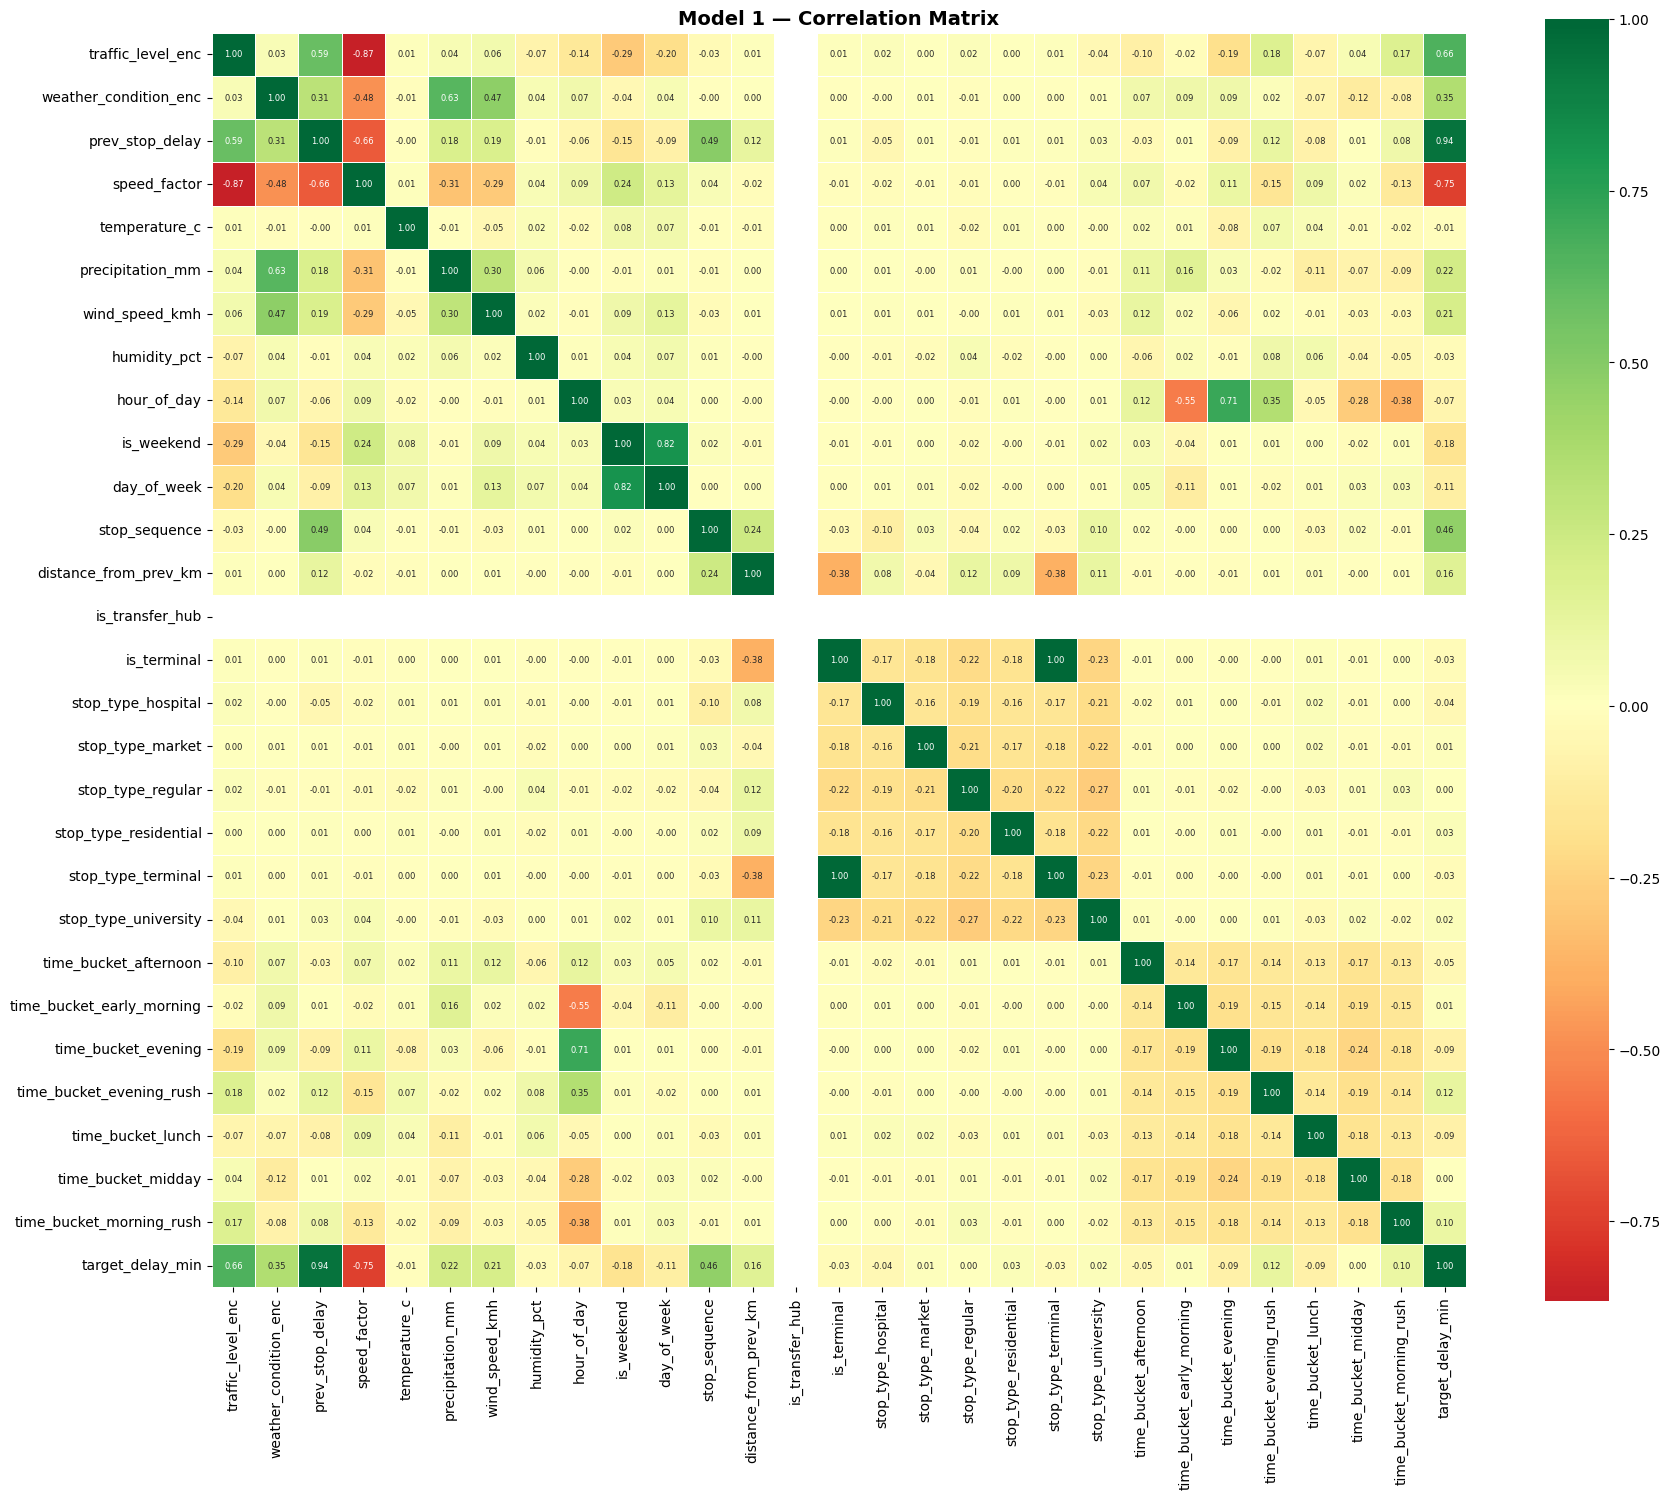

✅ Saved: data/model1_correlation.png


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. LOAD ───────────────────────────────────────────────────
stops   = pd.read_csv('data/bus_stops.csv')
trips   = pd.read_csv('data/bus_trips.csv')
arr     = pd.read_csv('data/stop_arrivals.csv')

# ── 2. MERGE trips → temperature_c, precipitation_mm, wind, humidity
# stop_arrivals has trip_id, bus_trips has weather numerics per trip
arr = arr.merge(
    trips[['trip_id', 'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'humidity_pct']],
    on='trip_id', how='left'
)

# ── 3. MERGE stops → is_transfer_hub ─────────────────────────
arr = arr.merge(
    stops[['stop_id', 'is_transfer_hub', 'is_terminal', 'distance_from_prev_km']],
    on='stop_id', how='left',
    suffixes=('', '_stops')
)

# ── 4. LAG FEATURE (prev stop delay) ─────────────────────────
arr = arr.sort_values(['trip_id', 'stop_sequence']).reset_index(drop=True)
arr['prev_stop_delay'] = arr.groupby('trip_id')['delay_min'].shift(1).fillna(0)

# ── 5. CLIP TARGET ────────────────────────────────────────────
arr['target_delay_min'] = arr['delay_min'].clip(lower=0, upper=30)

# ── 6. ORDINAL ENCODING ───────────────────────────────────────
# traffic: low=1.81 → moderate=5.73 → high=13.45 → congested=24.54
arr['traffic_level_enc'] = arr['traffic_level'].map(
    {'low': 0, 'moderate': 1, 'high': 2, 'congested': 3}
)
# weather: sorted by avg delay — clear=5.5 → cloudy=5.9 → wind=8.9 → rain=10.2 → fog=12.5 → snow=16.6
arr['weather_condition_enc'] = arr['weather_condition'].map(
    {'clear': 0, 'cloudy': 1, 'wind': 2, 'rain': 3, 'fog': 4, 'snow': 5}
)

# ── 7. ONE-HOT ENCODING ───────────────────────────────────────
arr = pd.get_dummies(arr, columns=['stop_type', 'time_bucket'], dtype=int)

# ── 8. SELECT FINAL COLUMNS ───────────────────────────────────
ohe_cols = [c for c in arr.columns if c.startswith(('stop_type_', 'time_bucket_'))]

final_cols = [
    # raw text (kept for reference)
    'traffic_level',
    'weather_condition',
    # ordinal encoded
    'traffic_level_enc',
    'weather_condition_enc',
    # numeric
    'prev_stop_delay',
    'speed_factor',
    'temperature_c',
    'precipitation_mm',
    'wind_speed_kmh',
    'humidity_pct',
    # time
    'hour_of_day',
    'is_weekend',
    'day_of_week',
    # stop
    'stop_sequence',
    'distance_from_prev_km',
    'is_transfer_hub',
    'is_terminal',
] + ohe_cols + ['target_delay_min']

df = arr[final_cols].dropna().reset_index(drop=True)
df.to_csv('data/model1_dataset.csv', index=False)
print(f"✅ Saved: data/model1_dataset.csv")
print(f"   Shape : {df.shape}")
print(f"   Columns ({len(df.columns)}):")
for c in df.columns:
    print(f"     {c}")

# ── 9. CORRELATIONS ───────────────────────────────────────────
numeric_df = df.drop(columns=['traffic_level', 'weather_condition'])
corr = numeric_df.corr()['target_delay_min'].drop('target_delay_min').dropna().sort_values(ascending=False)

print("\nCorrelations with target_delay_min:")
print("=" * 52)
for col, val in corr.items():
    bar = '█' * int(abs(val) * 30)
    sign = '+' if val > 0 else '-'
    print(f"  {sign} {col:<35} {val:>6.3f}  {bar}")

plt.figure(figsize=(18, 15))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 6})
plt.title('Model 1 — Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/model1_correlation.png', dpi=150)
plt.show()
print("✅ Saved: data/model1_correlation.png")

In [28]:
import pandas as pd
import numpy as np

# ── 1. LOAD ───────────────────────────────────────────────────
stops   = pd.read_csv('data/bus_stops.csv')
trips   = pd.read_csv('data/bus_trips.csv')
arr     = pd.read_csv('data/stop_arrivals.csv')

# ── 2. MERGE ──────────────────────────────────────────────────
arr = arr.merge(
    trips[['trip_id', 'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'humidity_pct']],
    on='trip_id', how='left'
)
arr = arr.merge(
    stops[['stop_id', 'is_transfer_hub', 'is_terminal', 'distance_from_prev_km']],
    on='stop_id', how='left', suffixes=('', '_stops')
)

# ── 3. LAG FEATURE + CLIP TARGET ──────────────────────────────
arr = arr.sort_values(['trip_id', 'stop_sequence']).reset_index(drop=True)
arr['prev_stop_delay'] = arr.groupby('trip_id')['delay_min'].shift(1).fillna(0)
arr['target_delay_min'] = arr['delay_min'].clip(lower=0, upper=30)

# ── 4. ORDINAL ENCODING ───────────────────────────────────────
arr['traffic_level_enc'] = arr['traffic_level'].map(
    {'low': 0, 'moderate': 1, 'high': 2, 'congested': 3}
)
arr['weather_condition_enc'] = arr['weather_condition'].map(
    {'clear': 0, 'cloudy': 1, 'wind': 2, 'rain': 3, 'fog': 4, 'snow': 5}
)

# ── 5. SELECT — only corr > 0.10 kept, drop weak features ─────
features = [
    'prev_stop_delay',       # +0.945
    'speed_factor',          # -0.747
    'traffic_level_enc',     # +0.662
    'weather_condition_enc', # +0.353
    'precipitation_mm',      # +0.220
    'wind_speed_kmh',        # +0.207
    'distance_from_prev_km', # +0.161
    'is_weekend',            # -0.177
    'day_of_week',           # -0.107
    'stop_sequence',         # +0.465
    'is_transfer_hub',
    'is_terminal',
    'target_delay_min'
]

df = arr[features].dropna().reset_index(drop=True)
df.to_csv('data/model1_dataset_linear.csv', index=False)
print(f"✅ Saved: data/model1_dataset_linear.csv")
print(f"   Shape : {df.shape}")
print(f"   Columns ({len(df.columns)}):")
for c in df.columns:
    print(f"     {c}")
print(f"\nTarget stats:")
print(df['target_delay_min'].describe().round(2))

✅ Saved: data/model1_dataset_linear.csv
   Shape : (4478, 13)
   Columns (13):
     prev_stop_delay
     speed_factor
     traffic_level_enc
     weather_condition_enc
     precipitation_mm
     wind_speed_kmh
     distance_from_prev_km
     is_weekend
     day_of_week
     stop_sequence
     is_transfer_hub
     is_terminal
     target_delay_min

Target stats:
count    4478.00
mean        7.59
std         8.53
min         0.00
25%         1.20
50%         4.30
75%        10.88
max        30.00
Name: target_delay_min, dtype: float64


In [34]:
# Second preprocessing for crowd prediction data
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("data/model_crowd_dataset.csv")
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} cols")

# Circular Encoding of Time
# This transforms time into a circle.
df["hour_sin"] = np.sin(2 * np.pi * df["hour_of_day"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour_of_day"] / 24)

# This transforms days into a circle.
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} cols")


# University at peak hour is a very different beast from regular at peak hour.
# This explicit interaction helps all three tree models split on it directly.
df["stop_x_hour_sin"] = df["stop_type_enc"] * df["hour_sin"]
df["stop_x_hour_cos"] = df["stop_type_enc"] * df["hour_cos"]
 
# Baseline crowd scaled by weather effect — rain at a busy stop hits harder.
df["baseline_x_weather"] = df["baseline_crowd"] * df["weather_condition_enc"]

df.drop(columns=["minutes_to_next_bus", "hour_of_day", "day_of_week"], inplace=True)
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} cols")

df.to_csv("data/model2_dataset.csv")



Loaded: 4478 rows × 11 cols
Loaded: 4478 rows × 15 cols
Loaded: 4478 rows × 15 cols


In [ ]:

warnings.filterwarnings('ignore')

# ── 1. Load ───────────────────────────────────────────────────────────────────
df      = pd.read_csv("data/model2_dataset.csv")
df_flow = pd.read_csv("data/passenger_flow.csv")
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} cols")

# ── 2. Fix 1: drop row index ──────────────────────────────────────────────────
df.drop(columns=["Unnamed: 0"], inplace=True)

# ── 3. Build target-encoding lookups from passenger_flow.csv ─────────────────
time_te_map = df_flow.groupby("time_bucket")["avg_passengers_waiting"].mean().to_dict()
weather_te_map = df_flow.groupby("weather_condition")["avg_passengers_waiting"].mean().to_dict()

# Confirmed label→string maps from encoding audit
TIME_LABEL_MAP = {
    0: "early_morning", 1: "morning_rush", 2: "midday",
    3: "lunch",         4: "afternoon",    5: "evening_rush", 6: "evening"
}
WEATHER_LABEL_MAP = {
    0: "clear", 1: "cloudy", 2: "wind",
    3: "fog",   4: "rain",   5: "snow"
}

# afternoon not in flow — interpolate lunch/evening_rush midpoint
time_te_map["afternoon"] = (time_te_map["lunch"] + time_te_map["evening_rush"]) / 2

# ── 4. Fix 2: replace time_bucket_enc with target-encoded values ──────────────
df["time_bucket_te"] = df["time_bucket_enc"].map(
    {enc: time_te_map[name] for enc, name in TIME_LABEL_MAP.items()}
)
df.drop(columns=["time_bucket_enc"], inplace=True)

# ── 5. Fix 3: rebuild baseline_x_weather using weather target encoding ────────
df["weather_te"] = df["weather_condition_enc"].map(
    {enc: weather_te_map[name] for enc, name in WEATHER_LABEL_MAP.items()}
)
df["baseline_x_weather"] = df["baseline_crowd"] * df["weather_te"]

# ── 6. Also rebuild stop_x_hour interactions using stop target encoding ───────
# (suboptimal fix: stop_type_enc was label int, replace with target-encoded)
STOP_LABEL_MAP = {0:"regular",1:"residential",2:"market",3:"hospital",4:"terminal",5:"university"} # The ordering matches actual average crowd (13 → 79 passengers), so the integer itself carries meaningful signal.
stop_te_map = df_flow.groupby("stop_type")["avg_passengers_waiting"].mean().to_dict()
df["stop_te"] = df["stop_type_enc"].map(
    {enc: stop_te_map[name] for enc, name in STOP_LABEL_MAP.items()}
)
df["stop_x_hour_sin"] = df["stop_te"] * df["hour_sin"]
df["stop_x_hour_cos"] = df["stop_te"] * df["hour_cos"]
df.drop(columns=["stop_te", "weather_te"], inplace=True)

print(f"After fixes: {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
df.to_csv("data/model2_dataset.csv")